# 004: Grain Mapping

Written by Jean-Baptiste Jacob

Last updated: 20/02/2026

### Map grains & grain boundaries using misorientation threshold 
- Map grain boundaries as pixels with high misorientation above some threshold
- Do grain segmentation to get the grain mask
- Refine average grain properties using all peaks from the grain masks
- Compute misorientation metrics like Kernel Average Misorentation and deviation from lmean grain orientation (GROD).

All this stuff can be done in MTex as well if you prefer. The export procedure to MTex file (.ctf) is shown at the end of the notebook. 

An alternative grain mapping procedure using density-beased clustering (DBSCAN) in orientation space is detailed in another notebook (`T004b_Grain_Mapping_DBSCAN`). Works better in 3D or for doing grain tracking in a s3DXRD time series but quite inefficient for large maps.   

### Load packages

In [1]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess


if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [2]:
# general modules
import os
import numpy as np
import matplotlib.pyplot as pl
from tqdm import tqdm

# ImageD11 + point-fit 3dxrd module
import ImageD11.grain
import ImageD11.columnfile
import ImageD11.sinograms.dataset
from pf3dxrd.pf3dxrd import utils, pixelmap, crystal_structure, orientation, peak_mapping, friedel_pairs

%matplotlib ipympl
%load_ext autoreload
%autoreload 2

### Load data
For now we need only the Pixelmap. We will also need the peakfile later, to refine the average grain orientations once they are segmented. 

In [3]:
# paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'

dsname = 'SI3_DT360Z5480'
#dsname = 'C18A_01_z180'

parfile= data_dir+'/SI3.par'
#parfile= data_dir+'/C18A_01.par'


In [4]:
def load_xmap(dsname):
    xmap_file = os.path.join(data_dir, f'{dsname}_xmap.h5')  
    xmap = pixelmap.load_from_hdf5(xmap_file)
    print(xmap)
    return xmap

def load_cf(dsname):
    peakfile = os.path.join(data_dir, f'{dsname}_pk2d_p_flt.h5')   
    dsfile = os.path.join(data_dir, f'{dsname}_dataset.h5')
    ds = ImageD11.sinograms.dataset.load(dsfile)
    
    cf = ImageD11.columnfile.columnfile(peakfile)
    cf.parameters.loadparameters(parfile)
    friedel_pairs.update_geometry_fpairs(cf, ds)
    
    # add pixel labeling to cf + sort by pixel index
    if not cf.sortedby == 'xyi':
        print('sorting peakfile by "xyi"...')
        cf.sortby('xyi')
        
    return cf 

In [5]:
xmap = load_xmap(dsname)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'GROD_angle', 'GROD_axis_xyz', 'KAM', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'gb_biotite', 'gb_magnetite', 'gb_misorientation_biotite', 'gb_misorientation_magnetite', 'gb_misorientation_oligoclase', 'gb_misorientation_orthoclase', 'gb_misorientation_quartz', 'gb_oligoclase', 'gb_orthoclase', 'gb_quartz', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell'], 
 grains: 94


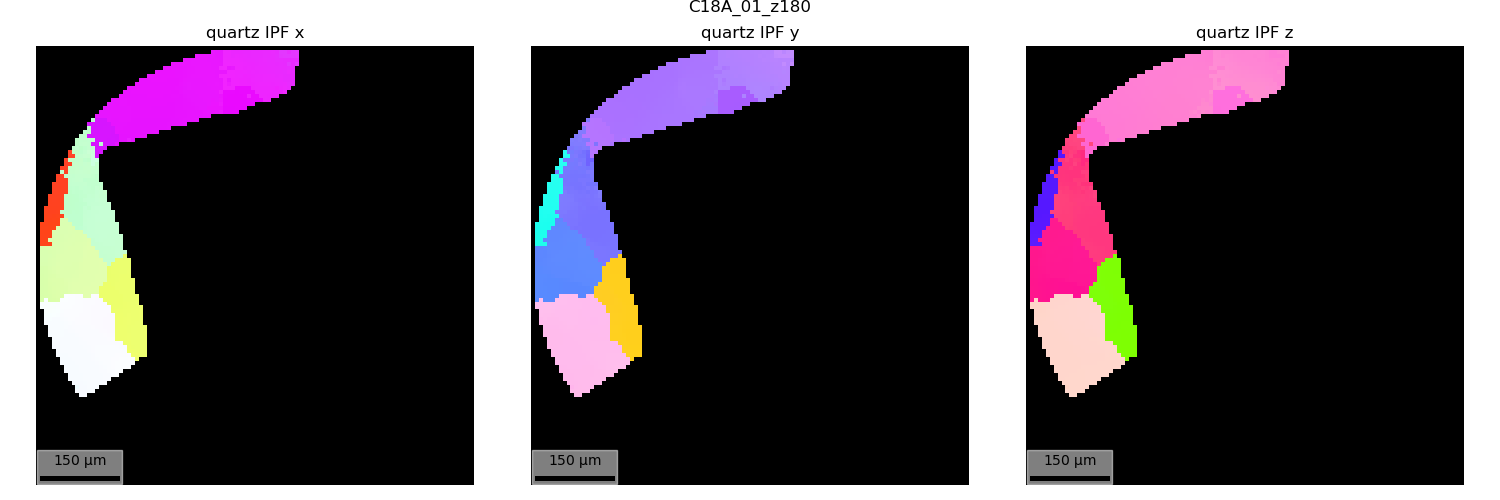

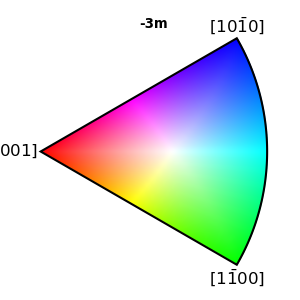

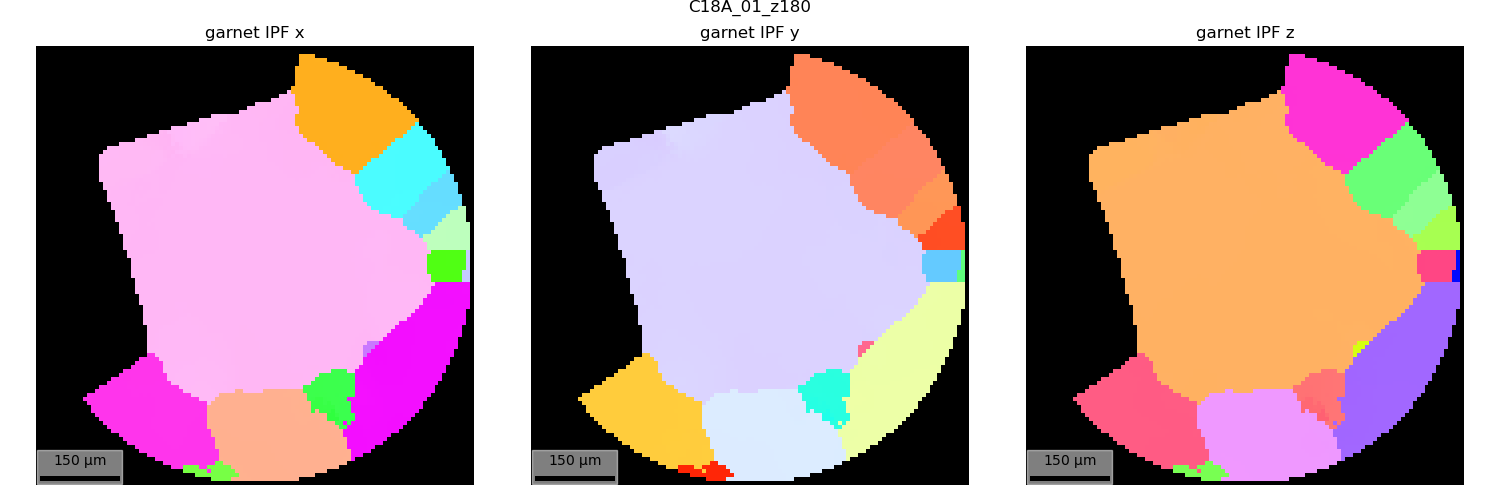

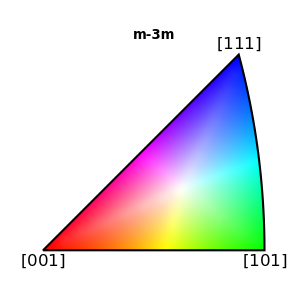

In [45]:
# plot orientation maps to have a look 
for pname in xmap.phases.pnames:
    # skip non-indexed phases
    pm = xmap.get_phase_mask(pname)
    if (pname =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue

    xmap.plot_ipf_orientation(phase=pname, ipf_directions='xyz', show_color_key=True)

### Map grain boundaries and label grains
The function `calcGrains` finds grain boundaries and does grain segmentation based on misorientation threshold. Similar conceptually to MTEX's calcGrains. It computes first the maximal misorientation with pixel neighbors (left-right and top-bottom) over the whole map and defines a grain boundary mask based on an angular threshold specified in input. Grains are then segmented by doing connected component analysis on the binary grain boundary mask. The function works for one phase at a time, so you have to iterate over each indexed phase. 

Grain boundariers are stored separately for each phase in data columns `gb_<phase>` and `gb_misorientation_<phase>`. `grain_id` is updated for each new phase with new grain labels. 

- threshold_deg (float, degree): angle threshold to identify a pixel as a boundary
- min_grain_size (int, pixel nb):  clear out small connected domains with less than N pixels 


In [46]:
# loop over each phase and mpa grain boundaries
xmap.grain_id = np.full(xmap.grain_id.shape, -1)  # initialize grain_id

for phase in xmap.phases.pnames:
    # skip non-indexed phases
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    xmap.calcGrains(phase, threshold_deg=5, min_grain_size=2)

Identified 7 grains for phase 'quartz'
Identified 12 grains for phase 'garnet'


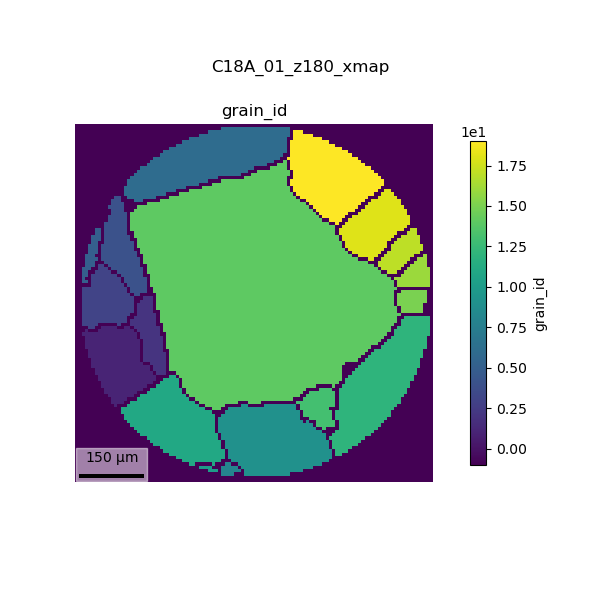

In [48]:
xmap.plot('grain_id')

There is an option for adding grain boundaries masks over xmap plots, by setting `show_gb = True`. This works for every data column, including also the ipf orientation maps. To use it, you must select a phase to plot. There are also two other parameters to control grain boundary aspect:
- `gb_color` : grain boundary color
- `gb_res_fact` : resolution factor; increases the grid size for the grain boundary mask -> makes thinner grain boundaries

If no grain boundary has been computed, it will try to compute them on the fly using default parameters in calcGrains.

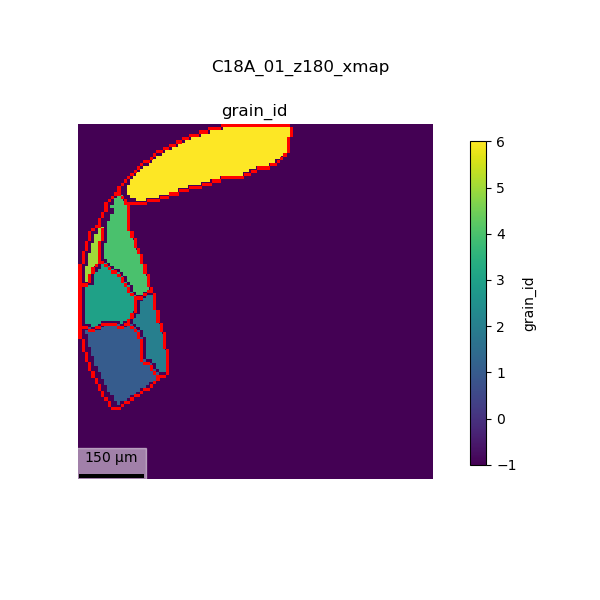

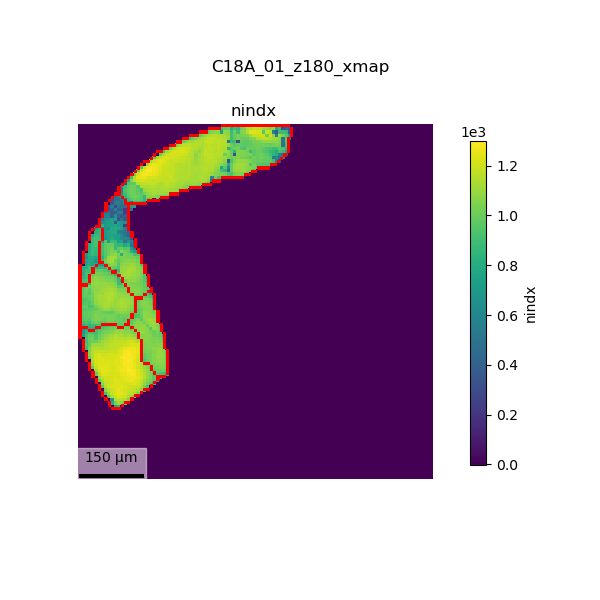

In [49]:
for key in ['grain_id', 'nindx']:
    xmap.plot(key, phase='quartz', show_gb=True, gb_color='r', gb_res_fact=1)    

It is also possible to add multiple grain boundaries (from different 'gb' columns) using the `add_grain_boundaries` method on an existing plot

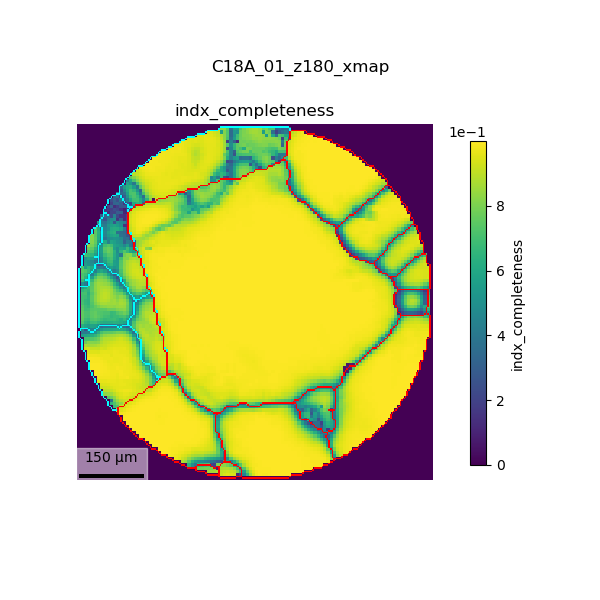

In [51]:
gb_col = ['none','cyan','r','lime','fuchsia']

# plot some data
fig = xmap.plot('indx_completeness', out=True)

# add grain boundaries overlaps
for i, phase in enumerate(xmap.phases.pnames):
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], gb_color=gb_col[i], resolution_factor=2)

#### FOR NOISY MAPS: Denoise orientation map

There is a (very basic) denoising function in `pf3dxrd/orientation` to get smoother grain boundaries (can help for grain mapping)

run the following cells for each phase to denoise -> will store smoothed orientation in U_smooth array 

**WARNING!!!** Make sure to write smoothed orientation in separate arrays (otherwise it will overwrite pre-indexed U column)

In [52]:
phase_to_denoise = 'quartz'

cs = xmap.phases.get(phase_to_denoise)
sym = cs.orix_phase.point_group.laue
nx, xb = xmap.grid.nx, xmap.grid.xbins

U = xmap.U.reshape(nx,nx,3,3)
pm = (xmap.phase_id == cs.phase_id)

In [53]:
# smoothing: compute new orientation array U_smooth. smoothing is done by averaging orientation in the local neighborhood of each pixel.
# kernel_size and threshold_deg control pixel neighbour selection: kernel_size:increases selection window; threshold_deg: excludes neighbors with too large misorientation
U_smooth = orientation.local_orientation_smooth_orix(U, sym, kernel_size=3, threshold_deg=10, global_mask = pm.reshape(nx,nx))

 76%|███████▌  | 82/108 [00:00<00:00, 121.99it/s]/cvmfs/hpc.esrf.fr/software/packages/linux/x86_64/jupyter-slurm/2025.04.5/envs/jupyter-slurm/lib/python3.12/site-packages/orix/quaternion/_conversions.py:1158: ComplexWarning: Casting complex values to real discards the imaginary part
  qu2d = qu2d.astype(np.float64)
100%|██████████| 108/108 [00:01<00:00, 106.14it/s]


Identified 6 grains for phase 'quartz'


/home/esrf/jean1994b/pf3dxrd/pf3dxrd/pixelmap.py:1160: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = pl.subplots(n_rows, n_cols, figsize=(5*n_cols,5*n_rows))


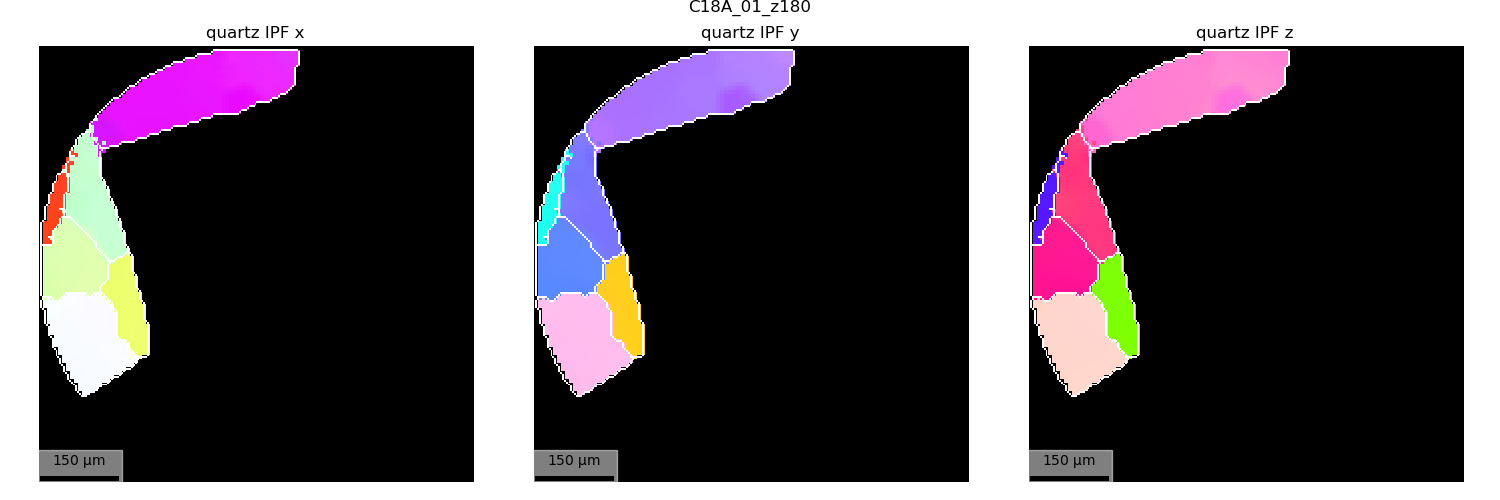

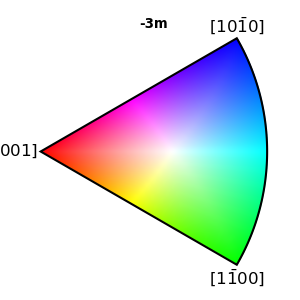

In [54]:
# segment grains with smoothed data

# add smoothed ori to xmap
xmap2 = xmap.copy()
if 'U_smooth' not in xmap2.titles():
    xmap2.add_data(np.zeros_like(xmap2.U),'U_smooth')
U_smooth = U_smooth.reshape(nx*nx,3,3)
xmap2.update_pixels('U_smooth', U_smooth[pm],selection_mask=pm)

# compute grain boundaries
xmap2.calcGrains(phase_to_denoise, Ucol='U_smooth', threshold_deg=2, min_grain_size=3)
xmap2.plot_ipf_orientation(phase=phase_to_denoise, datacolname='U_smooth', ipf_directions='xyz', show_gb=True, gb_color='w', gb_res_fact=2)

### map grain_id labels to grains dict
calcGrains updates the `grain_id` column but does not compute average grain properties neither creates new grains. For that we need to use the function `add_grains_from_map`, which will create new grains objects from the grain label map and store them in a dictionnary `xmap.grains.dict`.

In [55]:
# add grains to xmap.grains dict -> grain obj defined for each segmented domain and added to a dictionnary in xmap.grains
xmap.grains.__init__()

for phase in xmap.phases.pnames:
    
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    
    xmap.add_grains_from_map(phase, Ucol='U', overwrite=False)

print(xmap.grain_id.max(), max(xmap.grains.gids))    

100%|██████████| 13/13 [00:00<00:00, 20.92it/s]

19 19


In [56]:
xmap.grains.dict

{1: <ImageD11.grain.grain at 0xd5f50983d40>,
 2: <ImageD11.grain.grain at 0xd5f5144ef00>,
 3: <ImageD11.grain.grain at 0xd5f514ad8e0>,
 4: <ImageD11.grain.grain at 0xd5f51470ef0>,
 5: <ImageD11.grain.grain at 0xd5f514af6e0>,
 6: <ImageD11.grain.grain at 0xd5f5039b7a0>,
 8: <ImageD11.grain.grain at 0xd5f51243440>,
 9: <ImageD11.grain.grain at 0xd5f60201bb0>,
 10: <ImageD11.grain.grain at 0xd5f511f98b0>,
 11: <ImageD11.grain.grain at 0xd5f5053cef0>,
 12: <ImageD11.grain.grain at 0xd5f51470620>,
 13: <ImageD11.grain.grain at 0xd5f5092b290>,
 14: <ImageD11.grain.grain at 0xd5f50950bc0>,
 15: <ImageD11.grain.grain at 0xd5f509bb350>,
 16: <ImageD11.grain.grain at 0xd5f509ba960>,
 17: <ImageD11.grain.grain at 0xd5f50929010>,
 18: <ImageD11.grain.grain at 0xd5f509b94f0>,
 19: <ImageD11.grain.grain at 0xd5f50833440>}

In [57]:
# check grain mapping is consistent: same grain labels in xmap.grain_id and grain dict
np.all(np.equal(np.unique(xmap.grain_id)[1:], np.array(sorted(xmap.grains.gids))))

True

### Grain refinement
Grain mapping simply averages the unit cell and orientation over each segmented domain, which is a bit dodgy. To refine grains `UBI`, we use the peaks from the peakfile:

1) assign peaks in peakfile to grains in pixelmap based on grain masks
2) for each grain, select peaks from the peakfile, exclude outliers and merge by unique hkl
3) fit new grain UBI using the merged g-vectors, using a similar procedure as pixel-by-pixel indexing

In [58]:
# Sanity check: make sure grain labels are all consistent in xmap.grain_id, xmap.grains dict and peakfile
def check_grain_labels(cf, xmap):
    gids_xmap = np.unique(xmap.grain_id[xmap.phase_id != -1])
    gids_glist = np.unique(np.array(sorted(xmap.grains.gids)))
    gids_cf = np.unique(cf.grain_id)
    
    assert np.all(np.equal(gids_xmap[1:], gids_glist)), 'grain labels in xmap.grain_id and xmap.grains do not match'
    assert np.all(np.equal(gids_xmap, gids_cf)), 'grain labels in xmap and peakfile do not match'
    
    print('grain labels OK')

In [59]:
# load peakfile
cf = load_cf(dsname)

Reading your columnfile in hdf format
sorting peakfile by friedel pair index...
sorting peakfile by "xyi"...


In [60]:
# map peaks to grains
for pid, phase in zip(xmap.phases.pids, xmap.phases.pnames):
    # skip not indexed stuff
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    # first indexed phase (quartz): initialize grains dict
    if pid == 0:
        xmap.map_pks_to_grains(phase, cf, overwrite=True)
    # other phases: update grain dict
    else:
        xmap.map_pks_to_grains(phase, cf, overwrite=False)

peaks to grains mapping...


100%|██████████| 6/6 [00:00<00:00, 98.52it/s]


completed
peaks to grains mapping...


100%|██████████| 12/12 [00:00<00:00, 95.19it/s]

completed


In [61]:
# grain ids have been added to peakfile. We can check unique grain ids in poeakfile match those in pixelmap
check_grain_labels(cf, xmap)

grain labels OK


Now we can refine each grain `UBI` using all peaks assigned from the grain mask. 

**Notes**
- use large hkl tolerance here, because we want the "average" orientation of grains that can show large intra-granular orientation spread. If hkltol is too small, it will filter out most of the peaks from the grain 
- nmedian is an additional parameter to exclude outliers gvectors plotting too far away from the median of all g-vectors in the selection

In [62]:
# refine grain ubis based on all peaks mapped to each grains 
stats = {}
for pid, phase in zip(xmap.phases.pids, xmap.phases.pnames):
    # skip not indexed stuff
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    cs = xmap.phases.get(phase)
    stats[phase] = xmap.refine_grain_ubis(phase, cf, hkl_tol=.5, nmedian=10, sym = cs.orix_phase.point_group.laue)

refining ubis...


100%|██████████| 6/6 [00:02<00:00,  2.48it/s]


refining ubis...


100%|██████████| 12/12 [00:04<00:00,  2.64it/s]


`refine_grain_ubis` returns some statistics about refinement for each grain, stored in a dict: 
- `completeness`: similar to `indexing_completeness` in local indexing = fraction of indexed intensity but this time over the whole grain mask
- `mean_drlv2`  : mean deviation from hkl integer for all g-vectors used in the refinement
- `angle deviation` : rotation between older (non-refined) and new orientation matrix, in degree 

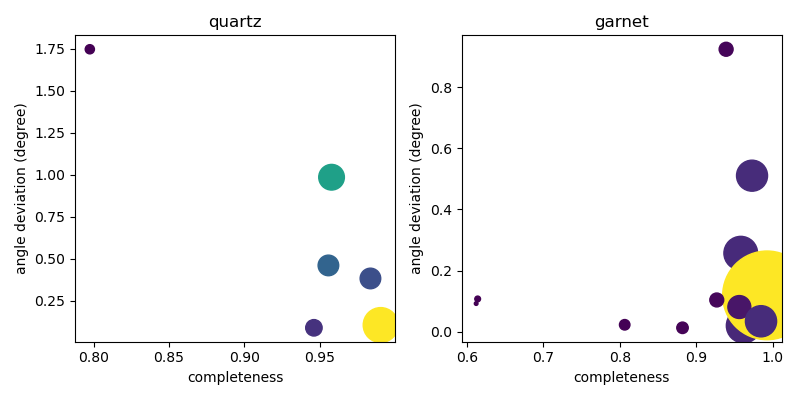

In [63]:
# completeness vs. angle deviation scatter plot, colored by total grain intensity
N = len(stats)

fig = pl.figure(figsize=(4*N,4))
for i,(pname,stat) in enumerate(stats.items()):
    ax = fig.add_subplot(1,N,i+1)
    ax.scatter(stat['completeness'], stat['angle deviation'],
           s=xmap.grains.get_all('grainsize', pname),
           c=xmap.grains.get_all('TotalIntensity', pname))
    ax.set(xlabel='completeness', ylabel='angle deviation (degree)')
    ax.set_title(pname)
fig.tight_layout()

### Misorientation
Compute compute misorientation metrics: Kernel average misorientation + Deviation from Mean grain orientation (GROD / Intragranular Misorientation)

In [64]:
# GROD: Grain Reference Orientation Deviation (see https://mtex-toolbox.github.io/EBSDGROD.html)
# returned as axis-angle orientation per pixel
xmap.calcGROD(pixel_orientation='U')

Computing GROD: 100%|██████████| 18/18 [00:00<00:00, 21.59it/s]


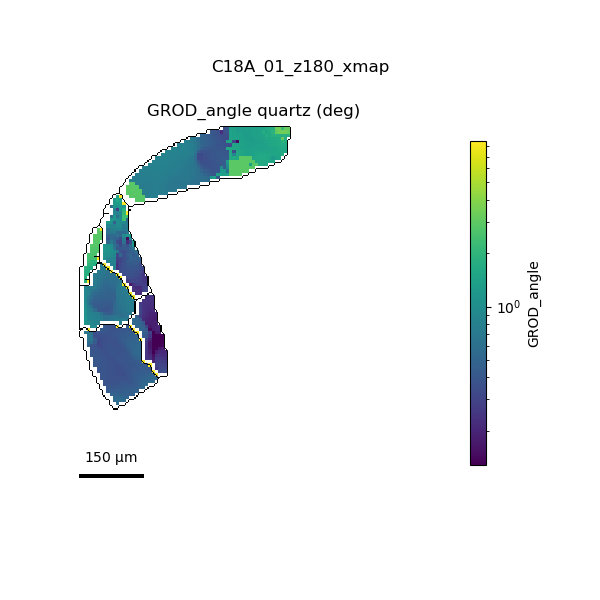

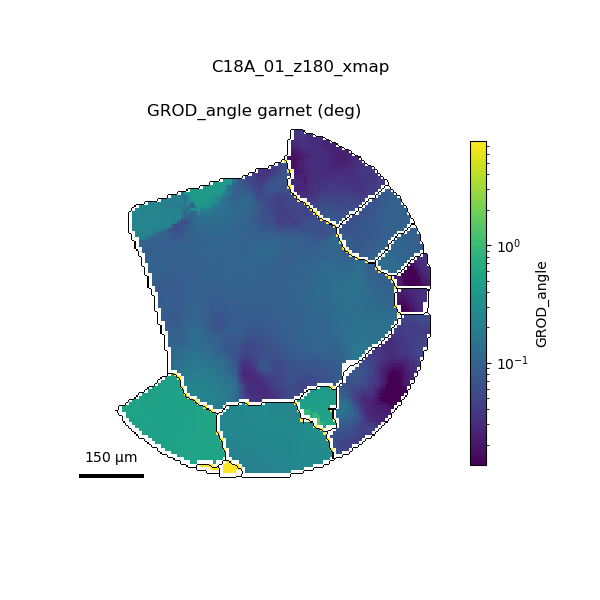

In [70]:
# same for each phase in separate plots
for phase in xmap.phases.pnames:
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
        
    low, up = np.percentile(xmap.GROD_angle[pm & (xmap.GROD_angle>0)], (1,99))
    
    fig = xmap.plot('GROD_angle', phase=phase, show_gb=True, gb_color='k',
              norm=pl.matplotlib.colors.LogNorm(vmin=low, vmax=up), out=True)

    fig.axes[0].set_title(f'GROD_angle {phase} (deg)')

Grain misorientation axis is also returned as a 3D vector in xyz sample coordinates. This can be used for further misorientation analysis and identification of slip systems (plastically deformed grains)

In [71]:
xmap.GROD_axis_xyz[xmap.GROD_angle>0]

array([[-0.83304664, -0.50505932, -0.22571749],
       [-0.83300728, -0.50500978, -0.22597345],
       [-0.83323561, -0.50472192, -0.22577467],
       ...,
       [ 0.59961792, -0.33545524, -0.72658663],
       [ 0.61644629, -0.39330575, -0.68213236],
       [ 0.6142998 , -0.38533912, -0.68858516]])

**Kernel Average Misorientation**

Local Misorientation is computed with the `calcKAM` function. Takes all pixels in local neighborhood and computes average misorientation. This has to be run phase by phase 
- kernel size : controls size of the neighborhood
- threshold_deg: exclude neighbors with too large misorientation (likely from different grains)
- use_numba_acceleration: fast mode to calculate misorientation by simple U matrix comparison, but ignores crystal symmetry
- mode: 'mean' or 'median' misorientation

In [72]:
# Kernel Average Misorientation
for phase in xmap.phases.pnames:
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
    xmap.calcKAM(phase, Ucol='U', kernel_size=3, threshold_deg=2, use_numba_acceleration=True, mode='mean')

⚡ Numba-accelerated mode (approximate, ignores symmetry)...
⚡ Numba-accelerated mode (approximate, ignores symmetry)...


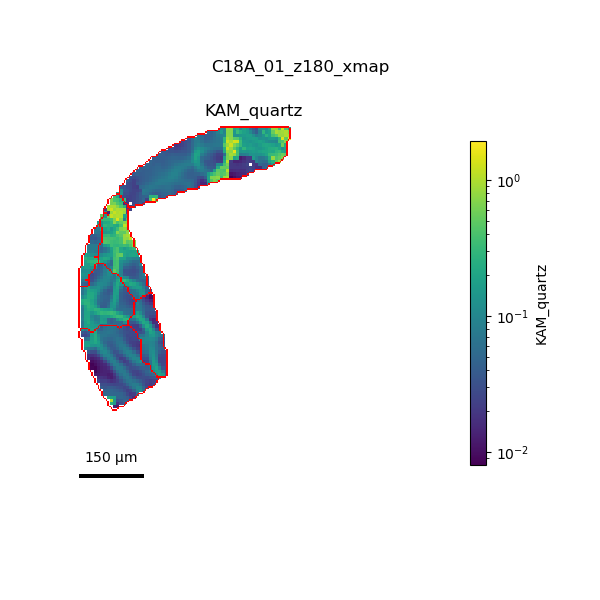

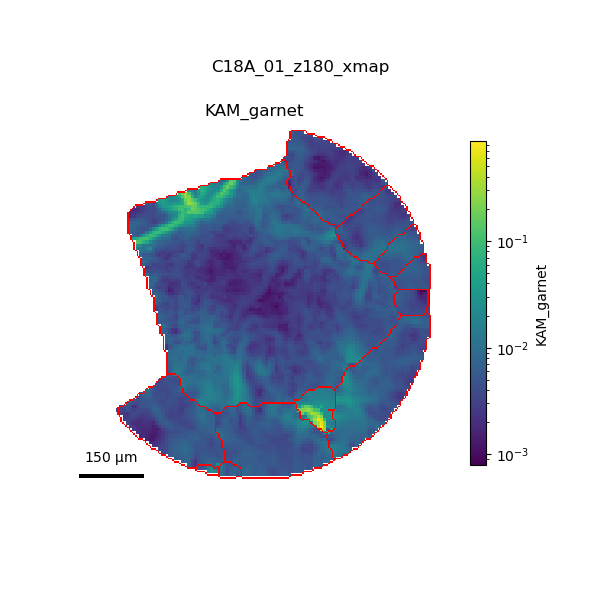

In [78]:
for phase in xmap.phases.pnames:
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
    xmap.plot(f'KAM_{phase}', phase=phase, show_gb=True, gb_color='r', gb_res_fact=2, autoscale=False, norm=pl.matplotlib.colors.LogNorm())

KAM is computed phase by phase and stored in different columns `KAM_<phase>`. It saves space to merge them into one single array.

In [79]:
# plot all KAM combined
KAM_merged = np.zeros_like(xmap.KAM_quartz)

for phase in xmap.phases.pnames:
    if f'KAM_{phase}' in xmap.titles():
        pm = xmap.get_phase_mask(phase)
        KAM_merged[pm] = xmap.get(f'KAM_{phase}')[pm]

xmap.add_data(KAM_merged,'KAM')

# delete former KAM_<phase> arrays
for p in xmap.phases.pnames:
    if f'KAM_{p}' in xmap.titles():
        delattr(xmap, f'KAM_{p}')

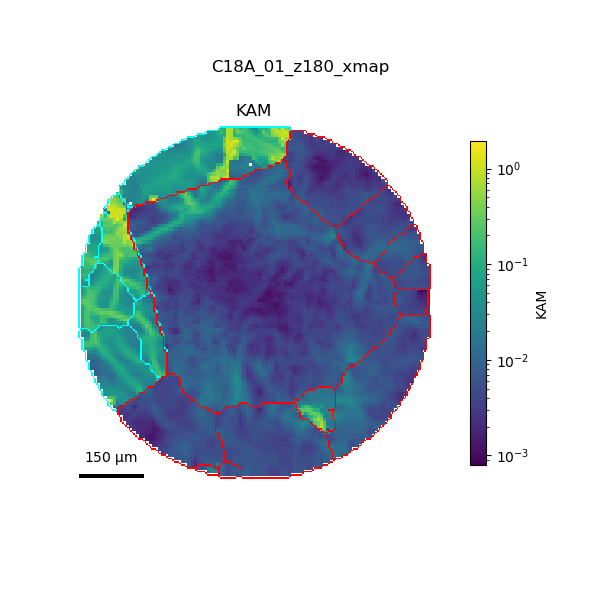

In [80]:
fig = xmap.plot('KAM', norm=pl.matplotlib.colors.LogNorm(), out=True)

for i, phase in enumerate(xmap.phases.pnames):
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], resolution_factor=2, gb_color=gb_col[i])

### Save refined map and peakfile

In [84]:
pksfile = os.path.join(data_dir, f'{dsname}_pk2d_p_flt.h5')
utils.colf_to_hdf(cf, pksfile, save_mode='minimal')   

In [85]:
xmap.save_to_hdf5()

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/C18A_01_z180/C18A_01_z180_xmap.h5


### Export to MTex .ctf File

There is a built-in method in ImageD11 `TensorMap` that we can use that to create a .ctf file that can be read in Mtex

In [81]:
# first convert xmap to TensorMap
tmap = xmap.to_tensor_map()

In [82]:
# xmap puts zeros 3x3 matrices as default 'notIndexed' orientation. Change to np.nan 
m = tmap.nindx <= 0
tmap.U[m] = np.nan

In [83]:
# then export to ctf
ctf_path = xmap.h5name.replace('.h5','.ctf')
tmap.to_ctf_mtex(ctf_path)

CTF exported!
In MTEX, run the command:
import_wizard('EBSD')
Click the '+', choose file /home/esrf/jean1994b/test_datasets/C18A_01_z180/C18A_01_z180_xmap.ctf and click 'Open'
Click 'Next >>'
Click 'Next >>' though the phases, changing if necessary (should be right though)
Choose 'apply rotation to Euler angles and spatial coordinates' with an angle of [0,0,0]
Choose the default MTEX plotting convention (X east, Y north)
Click 'Next >>' then 'script (m-file)' for the 'Import to', then 'Finish'
Click 'Run' at the top, save the import script somewhere, then it should run
Your EBSD should now be imported into MTEX. You can try to plot it with 'plot(ebsd)'
